# 結構方程模式 ① 基本概念(白話入門版)
### 三部曲之一 · 適合高中生

> 這是三份系列教材的**第一份**。先用最白話、最少數學的方式,把「結構方程模式 (Structural Equation Modeling, SEM) 到底在做什麼」講清楚。深入的數學與完整分析流程,放在後面兩份:
> - **②衡量模型**(怎麼「測量」看不見的東西)
> - **③結構模型**(看不見的東西之間「誰影響誰」)

---

## 一句話先記住

> **SEM 在研究「看不見的東西」之間的因果關係——而且是用「看得見的問卷分數」去推測它們。**

例如:「**顧客滿意度**會不會影響**忠誠度**?」——滿意度和忠誠度都是看不見、摸不到的心理感受,但我們可以用問卷把它們「測量」出來,再用 SEM 算出它們之間的影響有多大。

---
## 第 0 章　環境設定(執行一次就好)

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Ellipse, FancyBboxPatch, FancyArrowPatch

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)

def use_cjk_font():
    cands = ["Noto Sans CJK TC","Noto Sans CJK SC","Noto Sans TC","Microsoft JhengHei",
             "Microsoft YaHei","PingFang TC","Heiti TC","SimHei","Arial Unicode MS","WenQuanYi Zen Hei"]
    avail = {f.name for f in fm.fontManager.ttflist}
    for n in cands:
        if n in avail:
            matplotlib.rcParams["font.family"]=n; matplotlib.rcParams["axes.unicode_minus"]=False; return n
    import glob
    for fp in glob.glob("/usr/share/fonts/**/NotoSansCJK*.ttc", recursive=True):
        try:
            fm.fontManager.addfont(fp); matplotlib.rcParams["font.family"]="Noto Sans CJK TC"
            matplotlib.rcParams["axes.unicode_minus"]=False; return "Noto Sans CJK TC"
        except Exception: pass
    matplotlib.rcParams["axes.unicode_minus"]=False; return None
print("字型:", use_cjk_font() or "(無中文字型,圖表中文可能為方框)")

字型: WenQuanYi Zen Hei


In [2]:
def _trim(p1,p2,r1,r2):
    p1=np.array(p1,float);p2=np.array(p2,float);d=p2-p1;L=np.hypot(*d)
    if L==0: return p1,p2
    u=d/L; return p1+u*r1, p2-u*r2
def node(ax,xy,text,kind="latent",w=1.6,h=1.05,fs=10):
    x,y=xy
    if kind=="latent":
        ax.add_patch(Ellipse((x,y),w,h,facecolor="#dbeafe",edgecolor="#2563eb",lw=2,zorder=3))
    else:
        ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle="round,pad=0.02",
                     facecolor="#fef3c7",edgecolor="#d97706",lw=1.8,zorder=3))
    ax.text(x,y,text,ha="center",va="center",fontsize=fs,zorder=4)
def arrow(ax,p1,p2,label=None,curved=0.0,two_head=False,r1=0.85,r2=0.85,
          color="#374151",lw=1.7,dx=0.0,dy=0.18,fs=9):
    q1,q2=_trim(p1,p2,r1,r2)
    style="<->" if two_head else "-|>"
    ax.add_patch(FancyArrowPatch(q1,q2,arrowstyle=style,mutation_scale=14,
                 connectionstyle=f"arc3,rad={curved}",color=color,lw=lw,zorder=2))
    if label:
        mx,my=(q1[0]+q2[0])/2+dx,(q1[1]+q2[1])/2+dy
        ax.text(mx,my,label,ha="center",fontsize=fs,color=color,zorder=5,
                bbox=dict(boxstyle="round,pad=0.12",fc="white",ec="none",alpha=0.9))
print("繪圖工具 node() / arrow() 已就緒")

繪圖工具 node() / arrow() 已就緒


---
## 第 1 章　一個生活問題

假設你開了一家手搖飲店,想知道:**到底是什麼讓客人一再回購(忠誠)?**

你心裡有個理論:

> 「咖啡**品質**好 → 客人會**滿意** → 滿意的客人就會**忠誠**。」

問題來了:**品質感受、滿意度、忠誠度,這三樣東西你都看不到、量不到。** 你不能拿尺去量「滿意度有幾公分」。這就是社會科學最大的難題——研究的東西常常是**看不見的**。

SEM 就是為了解決這個難題而生的工具。

---
## 第 2 章　兩種變項:看得見 vs 看不見

SEM 把世界的變項分成兩種,這是**最重要的基礎觀念**:

| 名稱 | 又叫 | 符號 | 例子 | 看得見嗎? |
|---|---|---|---|---|
| **觀察變項** | 指標、題目 | 方框 ▢ | 問卷第 1 題打幾分 | ✅ 看得見 |
| **潛在變項** | 構面、因素 | 橢圓 ◯ | 滿意度、忠誠度 | ❌ 看不見 |

### 冰山比喻 🧊

把「滿意度」想成一座**冰山**:

- **水面下看不見的冰山主體** = 潛在變項(真正的滿意度)。
- **露出水面、看得見的尖端** = 觀察變項(你問的那幾道題目)。

我們沒辦法直接量冰山主體,但可以量「露出水面的部分」,再**反推**水面下有多大。問卷的每一題,都是「滿意度」這座冰山露出水面的一角。

> 所以我們不會只問一題,而是問**好幾題**(例如滿意度問 3 題),用多個角度去逼近那個看不見的構面——這正是上一份「因素分析」教材在做的事。

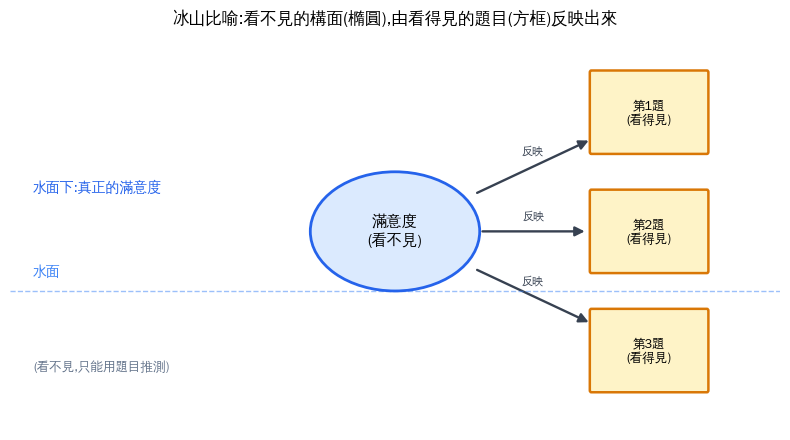

In [3]:
# 畫出「冰山」:一個看不見的構面,由 3 道看得見的題目反映
fig, ax = plt.subplots(figsize=(8,4.5))
node(ax,(5,3),"滿意度\n(看不見)",kind="latent",w=2.2,h=1.2,fs=11)
for i,y in enumerate([4.2,3,1.8]):
    node(ax,(8.3,y),f"第{i+1}題\n(看得見)",kind="obs",w=1.5,h=0.8,fs=9)
    arrow(ax,(5,3),(8.3,y),r1=1.1,r2=0.8,label="反映",dy=0.12,fs=8)
ax.axhline(2.4,color="#3b82f6",lw=1,ls="--",alpha=0.5)
ax.text(0.3,2.55,"水面",color="#3b82f6",fontsize=10)
ax.text(0.3,3.4,"水面下:真正的滿意度",color="#2563eb",fontsize=10)
ax.text(0.3,1.6,"(看不見,只能用題目推測)",color="#64748b",fontsize=9)
ax.set_xlim(0,10); ax.set_ylim(1,5); ax.axis("off")
ax.set_title("冰山比喻:看不見的構面(橢圓),由看得見的題目(方框)反映出來",fontsize=12)
plt.tight_layout(); plt.show()

---
## 第 3 章　SEM = 兩張拼圖合起來

SEM 之所以強大,是因為它把兩件事**同時**做完。這也是後面兩份文件的分工:

### 拼圖一:衡量模型 (Measurement Model)　→ 文件②

處理「**看不見的構面,怎麼由看得見的題目測量出來**」。也就是冰山比喻:每道題目和它背後的構面之間的關係(箭頭 ◯→▢)。這部分其實就是你學過的**因素分析**。

### 拼圖二:結構模型 (Structural Model)　→ 文件③

處理「**看不見的構面之間,誰影響誰、影響多大**」。也就是 ◯→◯ 的箭頭:品質 → 滿意度 → 忠誠。這部分像是「潛在變項版的迴歸」。

> **完整的 SEM = 衡量模型(拼圖一)+ 結構模型(拼圖二)。**
> 先確認「題目真的量到了構面」(拼圖一),再去談「構面之間的因果」(拼圖二)。

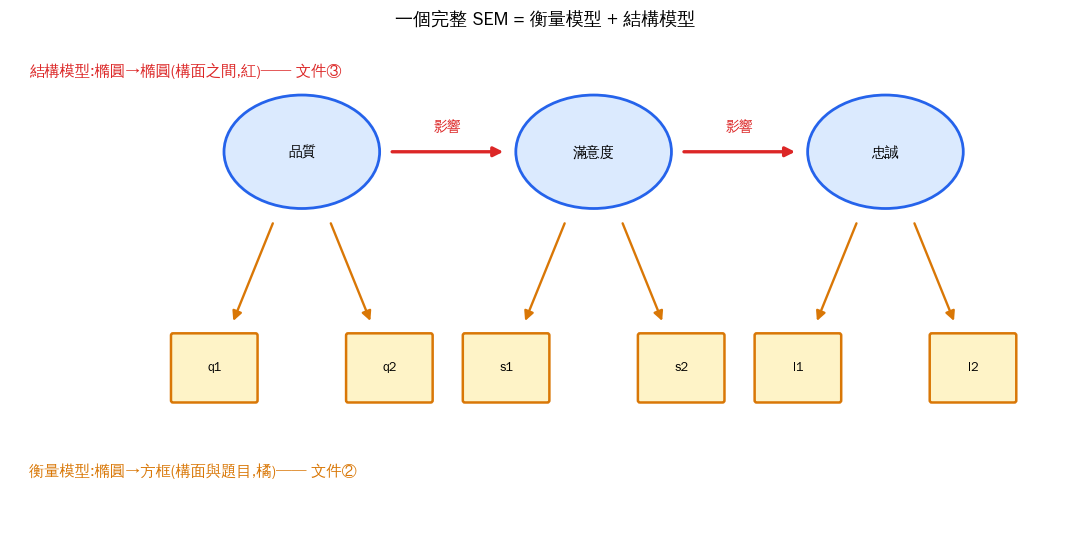

In [4]:
# 一張圖看懂兩張拼圖
fig, ax = plt.subplots(figsize=(11,5.5))
# 構面
node(ax,(3,4.2),"品質"); node(ax,(6,4.2),"滿意度"); node(ax,(9,4.2),"忠誠")
# 結構模型(◯→◯,紅色)
arrow(ax,(3,4.2),(6,4.2),label="影響",color="#dc2626",lw=2.4,r1=0.9,r2=0.9,fs=10)
arrow(ax,(6,4.2),(9,4.2),label="影響",color="#dc2626",lw=2.4,r1=0.9,r2=0.9,fs=10)
# 衡量模型(◯→▢,每構面 2 題示意)
for cx,lab in [(3,"q"),(6,"s"),(9,"l")]:
    for k,dx in enumerate([-0.9,0.9]):
        node(ax,(cx+dx,2.2),f"{lab}{k+1}",kind="obs",w=0.85,h=0.6,fs=9)
        arrow(ax,(cx,4.2),(cx+dx,2.2),r1=0.7,r2=0.45,color="#d97706")
ax.text(0.2,4.9,"結構模型:橢圓→橢圓(構面之間,紅)── 文件③",color="#dc2626",fontsize=11)
ax.text(0.2,1.2,"衡量模型:橢圓→方框(構面與題目,橘)── 文件②",color="#d97706",fontsize=11)
ax.set_xlim(0,11); ax.set_ylim(0.7,5.3); ax.axis("off")
ax.set_title("一個完整 SEM = 衡量模型 + 結構模型",fontsize=13)
plt.tight_layout(); plt.show()

---
## 第 4 章　SEM 的核心精神(白話版)

這是 SEM 最聰明的地方,用一個比喻講:

### 「劇本 vs 真實演出」比喻 🎭

- 你心中的理論(那些箭頭)= 一份**劇本**。劇本會**預測**:如果「品質→滿意→忠誠」是真的,那麼這 9 道題目的分數,彼此之間**應該**呈現某種特定的「一起高、一起低」的關聯模式。
- 你手上的問卷資料 = 演員的**真實演出**。每位顧客實際怎麼填,呈現出題目之間**實際**的關聯模式。
- **SEM 做的事**:比對「劇本預測的關聯」和「真實的關聯」像不像。
  - 像 → 你的理論(劇本)站得住腳 ✅
  - 不像 → 理論可能要修改 ❌

用比較專業一點的話說:

> 模型會推導出一個「**理論上應該有的關聯表**」(數學上叫 $\Sigma$),拿去跟資料算出的「**實際關聯表**」($S$)比對。兩張表越接近,模型越好。這就是 SEM 的靈魂:**讓 $\Sigma$ 盡量等於 $S$。**

下面用一個超簡單的數字示範這個「劇本能預測關聯」的概念。

In [5]:
# 示範:一個簡單「劇本」如何預測出關聯,再跟真實資料比對
# 劇本:X → Y,影響強度(路徑係數)= 0.7
rng = np.random.default_rng(1)
path = 0.7
X = rng.standard_normal(5000)
Y = path*X + np.sqrt(1-path**2)*rng.standard_normal(5000)   # 照劇本生成資料

predicted_corr = path                      # 劇本「預測」的相關 = 路徑係數
actual_corr = np.corrcoef(X, Y)[0,1]       # 資料「實際」的相關

print(f"劇本預測 X 與 Y 的相關 ≈ 路徑係數 = {predicted_corr}")
print(f"真實資料算出的相關         = {actual_corr:.3f}")
print(f"兩者很接近 → 這個『劇本』描述資料描述得不錯!")
print("\n👉 SEM 就是放大版:同時比對很多題目之間的關聯,看整套理論像不像。")

劇本預測 X 與 Y 的相關 ≈ 路徑係數 = 0.7
真實資料算出的相關         = 0.689
兩者很接近 → 這個『劇本』描述資料描述得不錯!

👉 SEM 就是放大版:同時比對很多題目之間的關聯,看整套理論像不像。


---
## 第 5 章　路徑圖怎麼看

SEM 的成果通常畫成一張**路徑圖 (path diagram)**,看懂它就看懂一半了:

| 符號 | 意思 |
|---|---|
| 橢圓 ◯ | 看不見的構面(潛在變項) |
| 方框 ▢ | 看得見的題目(觀察變項) |
| 單箭頭 → | 「影響」或「反映」(有方向) |
| 雙箭頭 ↔ | 「相關」(沒方向,只是一起變動) |
| 箭頭上的數字 | 影響的**強度**(越接近 ±1 越強;0 代表沒影響) |

看圖三步驟:**① 先找橢圓(構面)→ ② 看橢圓之間的箭頭(這是重點:因果)→ ③ 看箭頭上的數字(影響多大)。**

---
## 第 6 章　迷你實際示範(選讀 · 進階)

下面這格會真的「跑一個 SEM」,讓你先看一眼成品長怎樣。它需要 `semopy` 套件(後面兩份文件會用到);若你電腦還沒裝,可先跳過,只看輸出結果。

> 安裝方式(在終端機):`pip install semopy`

In [6]:
try:
    import semopy
    # 一個最簡單的模型:品質 → 忠誠(各 3 題)
    rng = np.random.default_rng(0); N=400
    Q = rng.standard_normal(N)
    Loy = 0.6*Q + np.sqrt(1-0.36)*rng.standard_normal(N)
    def ind(f,ld): return np.column_stack([l*f+np.sqrt(1-l**2)*rng.standard_normal(N) for l in ld])
    df = pd.DataFrame(np.column_stack([ind(Q,[0.8,0.75,0.7]), ind(Loy,[0.82,0.78,0.7])]),
                      columns=["q1","q2","q3","l1","l2","l3"])
    desc = "品質 =~ q1+q2+q3\n忠誠 =~ l1+l2+l3\n忠誠 ~ 品質"
    m = semopy.Model(desc); m.fit(df)
    r = m.inspect(std_est=True)
    beta = float(r[(r["lval"]=="忠誠")&(r["rval"]=="品質")&(r["op"]=="~")]["Est. Std"].iloc[0])
    print(f"SEM 算出:品質 → 忠誠 的影響強度 = {beta:.3f}")
    print("白話解讀:品質感受每提升 1 個標準差,忠誠度大約提升", round(beta,2), "個標準差。")
    print("數字為正且不小 → 『提升品質能增加忠誠』這個說法獲得資料支持。")
except ImportError:
    print("尚未安裝 semopy,可先跳過。安裝後即可看到結果:")
    print("預期輸出:品質 → 忠誠 的影響強度 ≈ 0.6(正向、中等偏強)")

SEM 算出:品質 → 忠誠 的影響強度 = 0.634
白話解讀:品質感受每提升 1 個標準差,忠誠度大約提升 0.63 個標準差。
數字為正且不小 → 『提升品質能增加忠誠』這個說法獲得資料支持。


---
## 第 7 章　三句話總結

1. **世界有兩種變項**:看得見的題目(▢)、看不見的構面(◯)。SEM 用前者推測後者。
2. **SEM 是兩張拼圖**:衡量模型(構面↔題目)+ 結構模型(構面→構面)。
3. **核心精神**:讓「理論預測的關聯 $\Sigma$」逼近「資料實際的關聯 $S$」,越像理論越成立。

### 接下來

| 文件 | 主題 | 你會學到 |
|---|---|---|
| **①(本篇)** | 基本概念 | 看懂 SEM 在做什麼 |
| **②衡量模型** | 怎麼測量構面 | 信度、效度、題目好不好 |
| **③結構模型** | 構面間的因果 | 假設檢定、影響多大、中介效果 |

準備好了,就翻開**文件②:衡量模型**,進入第一張拼圖的完整流程。